# **Project: Heart Disease Prediction**
By: Destiny Voyles-Perez


The purpose of this project is to create a predictive model using existing data about patient characteristics that resulted in a diagnosis of heart disease or no heart disease.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline


## EDA

In [ ]:
# Load the data

df = pd.read_csv('heart.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
# Review numeric variables. Compare mean and median to check if outliers are skewing results.
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


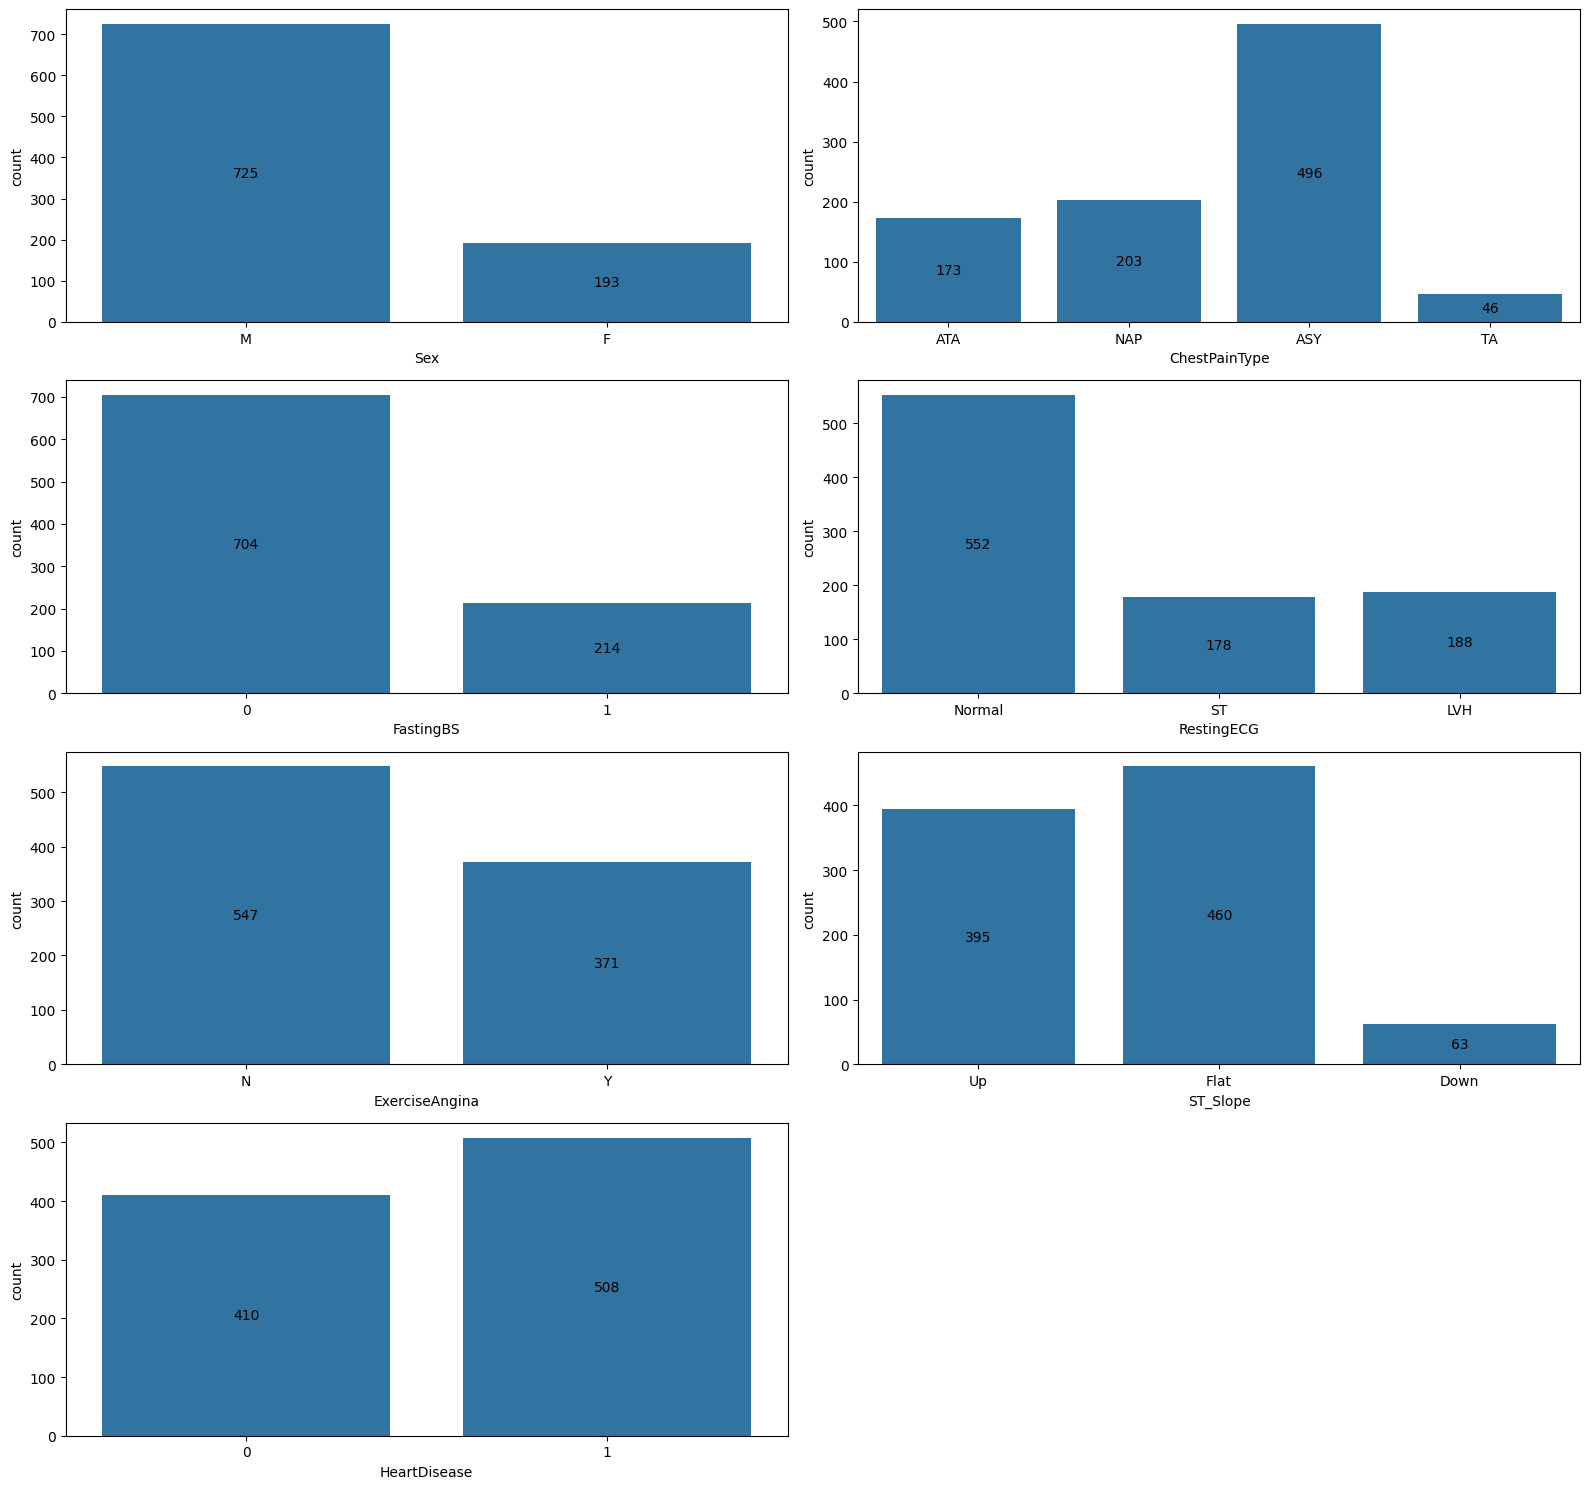

In [ ]:
# Look at non-numeric variables (with visuals)

categorical_cols = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

fig = plt.figure(figsize=(16, 15))
for i, col in enumerate(categorical_cols):
    ax = plt.subplot(4, 2, i+1)
    sns.countplot(x=df[col], ax=ax)

    for container in ax.containers:
        ax.bar_label(container, label_type="center")
    plt.tight_layout()



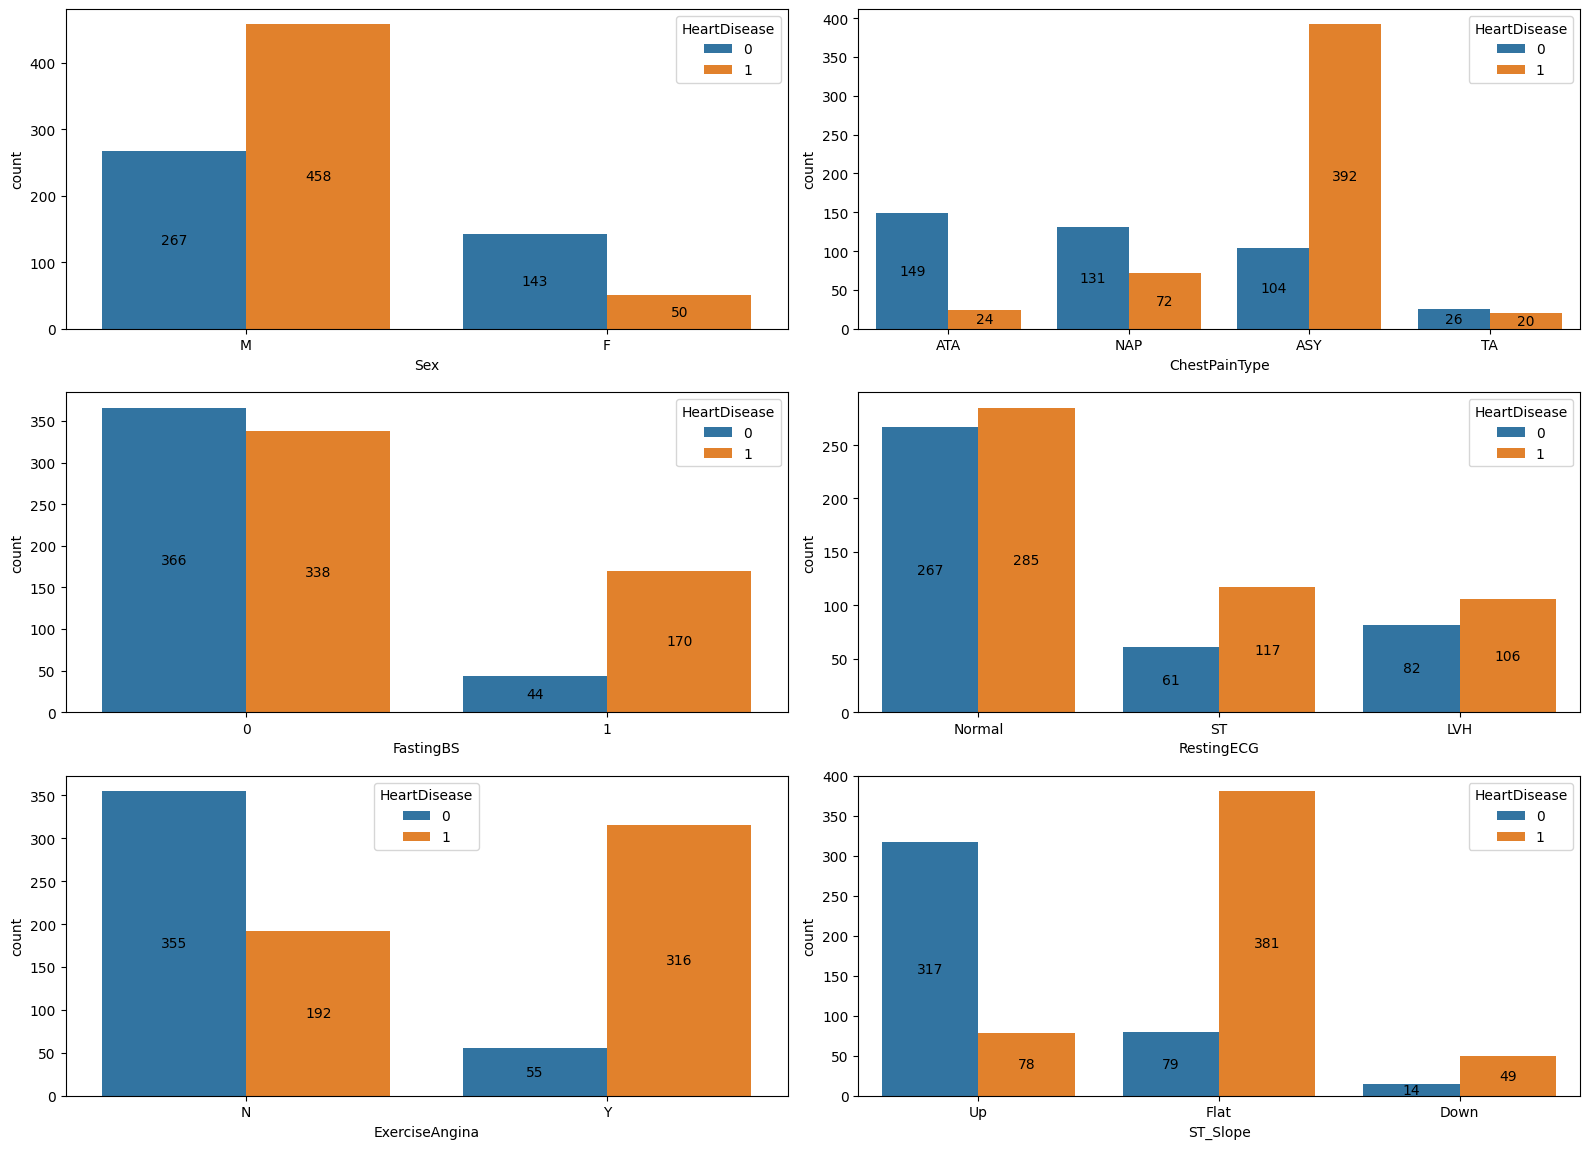

In [ ]:
fig = plt.figure(figsize=(16, 15))
for i, col in enumerate(categorical_cols[ :-1]):
    ax = plt.subplot(4, 2, i+1)
    #group by HeartDisease
    sns.countplot(x=df[col], hue=df['HeartDisease'], ax=ax)
    #add data labels to each bar
    for container in ax.containers:
        ax.bar_label(container, label_type="center")
    plt.tight_layout()

In [ ]:
#Check instances where Cholestrol is 0
df[df['Cholesterol'] == 0].info()

<class 'pandas.core.frame.DataFrame'>
Index: 172 entries, 293 to 536
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             172 non-null    int64  
 1   Sex             172 non-null    object 
 2   ChestPainType   172 non-null    object 
 3   RestingBP       172 non-null    int64  
 4   Cholesterol     172 non-null    int64  
 5   FastingBS       172 non-null    int64  
 6   RestingECG      172 non-null    object 
 7   MaxHR           172 non-null    int64  
 8   ExerciseAngina  172 non-null    object 
 9   Oldpeak         172 non-null    float64
 10  ST_Slope        172 non-null    object 
 11  HeartDisease    172 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 17.5+ KB


##Data Cleaning

In [ ]:
# Create a copy

df_clean = df.copy()

#Remove the single instance of RestingBP = 0
df_clean = df_clean[df_clean['RestingBP'] != 0]

#Create a mask of HeartDisease
HD_mask = df_clean['HeartDisease'] == 0

chol_wo_hd = df_clean.loc[HD_mask,'Cholesterol']
chol_w_hd = df_clean.loc[~HD_mask,'Cholesterol']

#Replace the instance of 0 Cholesterol with the median, grouped by heart disease
df_clean.loc[HD_mask,'Cholesterol'] = chol_wo_hd.replace(0, chol_wo_hd.median())
df_clean.loc[~HD_mask,'Cholesterol'] = chol_w_hd.replace(0, chol_w_hd.median())


In [ ]:
df_clean[['Cholesterol', 'RestingBP']].describe()

,Cholesterol,RestingBP
count,917.000000,917.000000
mean,239.700109,132.540894
std,54.352727,17.999749
min,85.000000,80.000000
25%,214.000000,120.000000
50%,225.000000,130.000000
75%,267.000000,140.000000
max,603.000000,200.000000


### Feature Engineering


In [ ]:
# Convert categorical columns to numeric
df_clean = pd.get_dummies(df_clean, drop_first=True)
df_clean.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


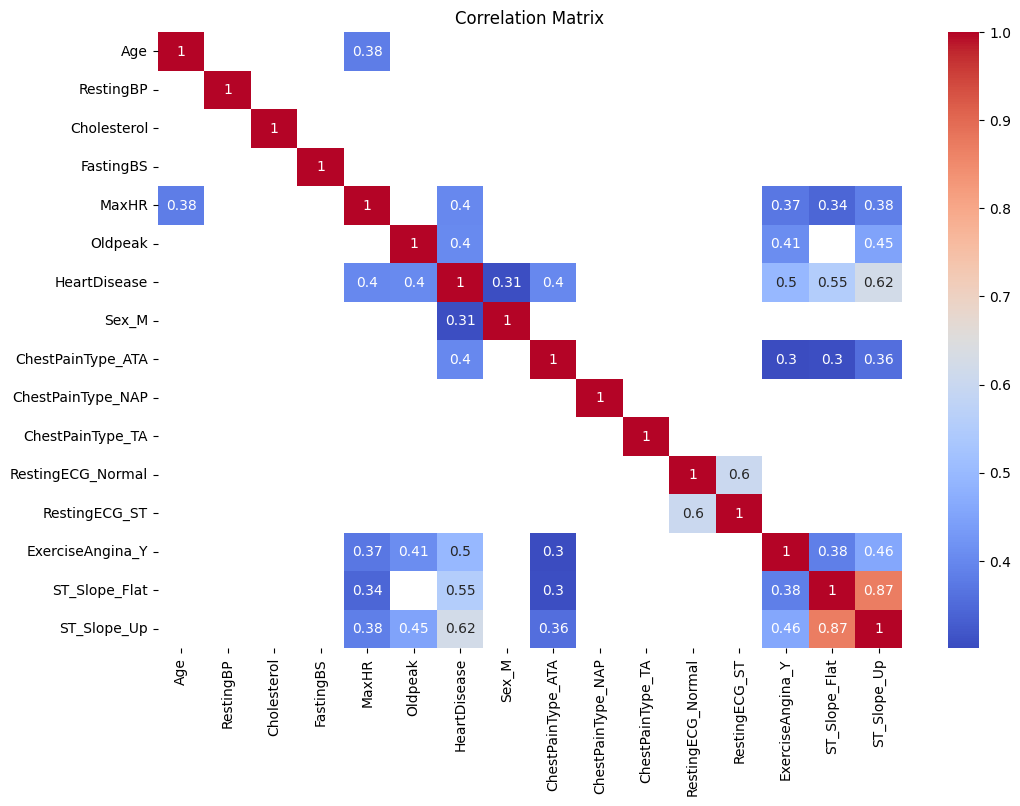

In [ ]:
# Calculate Correlations

correlations = abs(df_clean.corr())
plt.figure(figsize=(12, 8))
sns.heatmap(correlations[correlations > 0.30], annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Splitting train/test sets
X = df_clean.drop('HeartDisease', axis=1)
y = df_clean['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=123)

features = [
    'MaxHR',
    'Oldpeak',
    'Sex_M',
    'ExerciseAngina_Y',
    'ST_Slope_Flat',
    'ST_Slope_Up'
]

for feature in features:
  knn = KNeighborsClassifier(n_neighbors=3)
  knn.fit(X_train[[feature]], y_train)
  accuracy = knn.score(X_test[[feature]], y_test)
  print(f"Accuracy for {feature}: {accuracy*100:.2f}% when k = 3.")

Accuracy for MaxHR: 59.42% when k = 3.
Accuracy for Oldpeak: 65.22% when k = 3.
Accuracy for Sex_M: 52.90% when k = 3.
Accuracy for ExerciseAngina_Y: 76.09% when k = 3.
Accuracy for ST_Slope_Flat: 80.43% when k = 3.
Accuracy for ST_Slope_Up: 81.88% when k = 3.


In [ ]:
# Train on all features

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[features])
X_test_scaled = scaler.transform(X_test[features])

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)
accuracy = knn.score(X_test_scaled, y_test)
print(f"Accuracy for all features: {accuracy*100:.2f}% when k = 3.")

Accuracy for all features: 82.61% when k = 3.


In [ ]:
# Optimization

X = df_clean.drop('HeartDisease', axis=1)
y = df_clean['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=123)

features = [
    'MaxHR',
    'Oldpeak',
    #'Sex_M', # does this feature affect outcome
    'ExerciseAngina_Y',
    'ST_Slope_Flat',
    'ST_Slope_Up'
]

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[features])

In [ ]:
grid_params = {
    'n_neighbors': range(1, 20),
    'metric': ['minkowski', 'manhattan']
}

knn= KNeighborsClassifier()
knn_grid = GridSearchCV(knn, grid_params, scoring='accuracy')
knn_grid.fit(X_train_scaled, y_train);


In [ ]:
print(f"Best score: {knn_grid.best_score_*100:.2f}%")
print(f"Best parameters: {knn_grid.best_params_}")

Best score: 82.68%
Best parameters: {'metric': 'manhattan', 'n_neighbors': 13}


In [ ]:
# Test the scaled data

X_test_scaled = scaler.transform(X_test[features])
y_pred = knn_grid.best_estimator_.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy on test set: {accuracy*100:.2f}%")


Model accuracy on test set: 83.33%


In [ ]:
# Check distribution by sex

print('Distribution of patients by their sex in the entire dataset:')
print(X.Sex_M.value_counts())
Male = 724/(724+193)
Female = 193/(724+193)
print(f'Male: {Male*100:.2f}%')
print(f'Female: {Female*100:.2f}%')

print('\nDistribution of patients by their sex in the training dataset:')
print(X_train.Sex_M.value_counts())
Male2 = 613/(613+166)
Female2 = 166/(613+166)
print(f'Male: {Male2*100:.2f}%')
print(f'Female: {Female2*100:.2f}%')

print('\nDistribution of patients by their sex in the test dataset:')
print(X_test.Sex_M.value_counts())
Male3 = 111/(111+27)
Female3 = 27/(111+27)
print(f'Male: {Male3*100:.2f}%')
print(f'Female: {Female3*100:.2f}%')

Distribution of patients by their sex in the entire dataset:
Sex_M
True     724
False    193
Name: count, dtype: int64
Male: 78.95%
Female: 21.05%

Distribution of patients by their sex in the training dataset:
Sex_M
True     613
False    166
Name: count, dtype: int64
Male: 78.69%
Female: 21.31%

Distribution of patients by their sex in the test dataset:
Sex_M
True     111
False     27
Name: count, dtype: int64
Male: 80.43%
Female: 19.57%


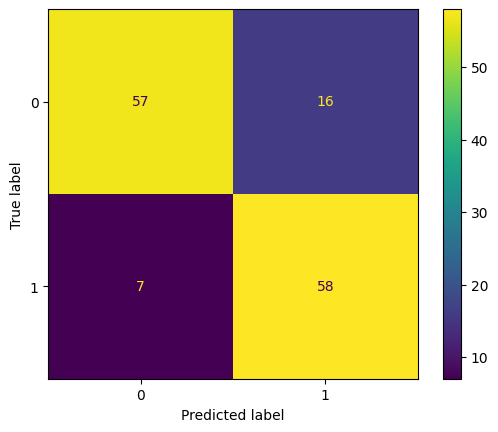

In [ ]:
# Confusion Matrix
cf = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cf)
disp.plot()
plt.show()

## Conclusions

My model predicted heart disease with 83.33% accuracy. My model was able to outperform the model trained on indiviual features (best score: ST_Slope Flat- 81.88%) and the model trained on all features (82.61%). Through continued feature engineering and testing other random states, the model could be improved. If I were to explore further, I would remove any features that have a correlation score to heart disease of less than .5 to see if this would improve my model.

  